# Workshop 2 — ASR: Inference & Evaluation (live)

We follow one Kazakh clip through **Whisper** (how ASR *runs*), then race two **Omnilingual
ASR** models — a **CTC** model vs an **autoregressive LLM** model — on **speed** and **WER**
(how we *evaluate*). Runs on the workshop GPUs. I drive; you predict and react.

## Setup — imports & Whisper

In [1]:
%matplotlib inline
import io, os, re, time
import numpy as np, torch, soundfile as sf, librosa
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from transformers import WhisperForConditionalGeneration, WhisperProcessor
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()
torch.set_grad_enabled(False)
device = "cuda" if torch.cuda.is_available() else "cpu"
SR = 16000

proc = WhisperProcessor.from_pretrained("openai/whisper-small")
whisper = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small").to(device).eval()
print("device:", device, "| loaded whisper-small")

device: cuda | loaded whisper-small


## The dataset — Google FLEURS (Kazakh), straight from HuggingFace

💬 *FLEURS is a multilingual speech benchmark. One line pulls the Kazakh test split from the Hub;
printing the dataset shows its **columns** and **size**.*

In [2]:
from datasets import load_dataset, Audio as HFAudio
fleurs = load_dataset("google/fleurs", "kk_kz", split="test")
print(fleurs)            # the dataset's columns (features) and number of rows

Dataset({
    features: ['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id'],
    num_rows: 856
})


Each row is an **audio** clip + its **transcription** (plus metadata like gender/language).
We tell `datasets` *not* to auto-decode the audio (avoids the heavy `torchcodec` dependency) and
decode it ourselves with `soundfile`.

In [3]:
fleurs = fleurs.cast_column("audio", HFAudio(decode=False))   # keep audio as raw bytes
ex = fleurs[0]
print("columns      :", fleurs.column_names)
print("transcription:", ex["transcription"][:80])
print("audio field  :", list(ex["audio"].keys()), "| gender:", ex["gender"])
print("# clips      :", len(fleurs))

def get_clip(i):
    s = fleurs[i]
    arr, _ = sf.read(io.BytesIO(s["audio"]["bytes"]))     # bytes -> 16 kHz waveform
    return arr.astype("float32"), s["transcription"]

columns      : ['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id']
transcription: ақш-тың гимнастика федерациясы ақш олимпиада комитетінің хатын қолдайды және біз
audio field  : ['bytes', 'path'] | gender: 0
# clips      : 856


## 1 · Inference — follow one clip through Whisper

💬 *Pick a clip, read its reference, and listen.*

In [4]:
i = 0                      # 💬 change the index to try other clips
audio, ref = get_clip(i)
print("reference:", ref)
display(Audio(audio, rate=SR))

reference: ақш-тың гимнастика федерациясы ақш олимпиада комитетінің хатын қолдайды және біздің барлық спортсмендер үшін қоршаған ортаның қауіпсіздігін арттырудың абсолютті қажеттілігін мойындайды


### A spectrogram is what Whisper actually "sees"

💬 *The audio becomes a log-mel spectrogram: pitch up, time across — a picture of sound.*

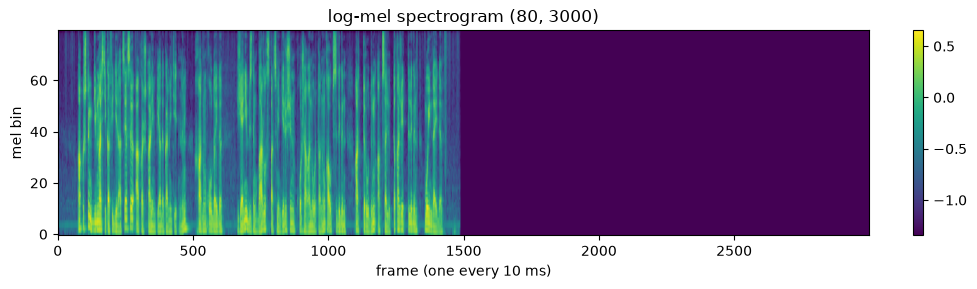

In [5]:
feats = proc(audio, sampling_rate=SR, return_tensors="pt").input_features   # [1, n_mels, 3000]
mel = feats[0].cpu().numpy()
plt.figure(figsize=(10, 3)); plt.imshow(mel, aspect="auto", origin="lower", cmap="viridis")
plt.xlabel("frame (one every 10 ms)"); plt.ylabel("mel bin"); plt.title(f"log-mel spectrogram {mel.shape}")
plt.colorbar(fraction=0.025); plt.tight_layout(); plt.show()

### Watch the decoder write tokens, one at a time

💬 *This is the autoregressive next-token loop from Session 1 — now conditioned on audio.*

In [11]:
from IPython.display import clear_output
enc = whisper.model.encoder(feats.to(device)).last_hidden_state
forced = [t for _, t in proc.get_decoder_prompt_ids(language="kazakh", task="transcribe")]
seq = [whisper.config.decoder_start_token_id] + forced
for _ in range(120):
    out = whisper(decoder_input_ids=torch.tensor([seq], device=device), encoder_outputs=(enc,))
    nxt = out.logits[0, -1].argmax().item()
    seq.append(nxt)
    if nxt == whisper.config.eos_token_id:
        break
    clear_output(wait=True)                                  # reprint the growing transcript (clean UTF-8)
    print(proc.decode(seq[len(forced) + 1:], skip_special_tokens=True))
    time.sleep(0.03)                                         # slow enough to watch it 'type'

 Ақыштың димнастика федерациясы Ақыш Олимпиады қамитетінің ханғылдайды, және біздің барлық спартсмендерішін, хоршаған үртаның қаупсыдың, арттырудың абсалюттық ажеттілің бойындайды.


### The hidden special tokens — Whisper's multitask format

💬 *Before any words, Whisper emits control tokens: start, language, task, no-timestamps.*

In [8]:
print([proc.decode([t]) for t in seq[:4]])

['<|startoftranscript|>', '<|kk|>', '<|transcribe|>', '<|notimestamps|>']


## 1b · The #1 real-world bug — wrong sample rate

💬 *Whisper assumes 16 kHz. Feed it audio at the wrong rate, **listen** to what it "hears,"
look at the distorted spectrogram, and watch the transcript fall apart.*

Whisper now 'hears' this (sped up / distorted):


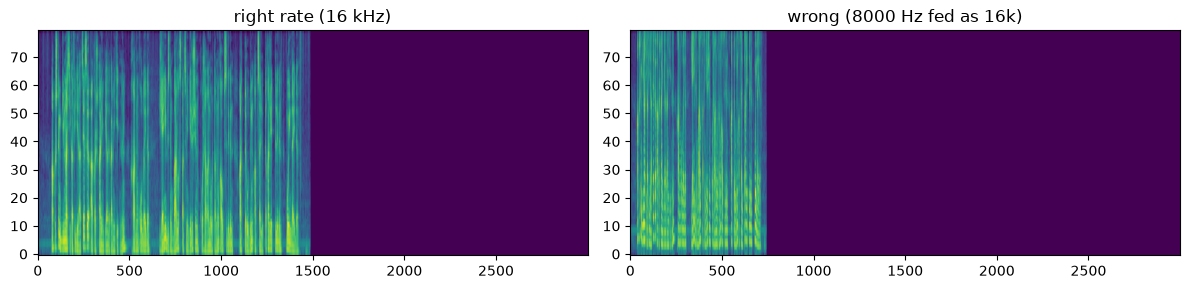

right rate :  Ақыштың димнастика федерациясы Ақыш Олимпиады қамитетінің ханғылдайды, және біздің барлық
wrong rate :  Апыштың гимнастика федерациясы апыш алимпиады қанекетін, хадың қолдайды жәгі діздің барығ


In [12]:
WRONG = 8000
audio_wrong = librosa.resample(audio, orig_sr=SR, target_sr=WRONG)        # WRONG-rate content...
feats_wrong = proc(audio_wrong, sampling_rate=SR, return_tensors="pt").input_features  # ...fed as 16 kHz
print("Whisper now 'hears' this (sped up / distorted):")
display(Audio(audio_wrong, rate=SR))

fig, ax = plt.subplots(1, 2, figsize=(12, 3))
ax[0].imshow(feats[0].cpu().numpy(), aspect="auto", origin="lower", cmap="viridis"); ax[0].set_title("right rate (16 kHz)")
ax[1].imshow(feats_wrong[0].cpu().numpy(), aspect="auto", origin="lower", cmap="viridis"); ax[1].set_title(f"wrong ({WRONG} Hz fed as 16k)")
plt.tight_layout(); plt.show()

def whisper_text(features):
    ids = whisper.generate(features.to(device), language="kazakh", task="transcribe")
    return proc.batch_decode(ids, skip_special_tokens=True)[0]
print("right rate :", whisper_text(feats)[:90])
print("wrong rate :", whisper_text(feats_wrong)[:90])

## 2 · Evaluation — CTC vs autoregressive (Omnilingual ASR)

💬 *Same model family, two decoding paradigms: a **CTC** model (one parallel pass) vs an
**autoregressive LLM** model (token by token). Race them on 50 Kazakh clips — speed and WER.*

In [15]:
N = 50
os.makedirs("tmp/kk_eval", exist_ok=True)
files, refs = [], []
for k in range(N):
    a, r = get_clip(k)
    p = f"tmp/kk_eval/{k}.wav"; sf.write(p, a, SR)
    files.append(p); refs.append(r)
print("wrote", N, "clips for evaluation")

wrote 50 clips for evaluation


In [17]:
print(files)

['tmp/kk_eval/0.wav', 'tmp/kk_eval/1.wav', 'tmp/kk_eval/2.wav', 'tmp/kk_eval/3.wav', 'tmp/kk_eval/4.wav', 'tmp/kk_eval/5.wav', 'tmp/kk_eval/6.wav', 'tmp/kk_eval/7.wav', 'tmp/kk_eval/8.wav', 'tmp/kk_eval/9.wav', 'tmp/kk_eval/10.wav', 'tmp/kk_eval/11.wav', 'tmp/kk_eval/12.wav', 'tmp/kk_eval/13.wav', 'tmp/kk_eval/14.wav', 'tmp/kk_eval/15.wav', 'tmp/kk_eval/16.wav', 'tmp/kk_eval/17.wav', 'tmp/kk_eval/18.wav', 'tmp/kk_eval/19.wav', 'tmp/kk_eval/20.wav', 'tmp/kk_eval/21.wav', 'tmp/kk_eval/22.wav', 'tmp/kk_eval/23.wav', 'tmp/kk_eval/24.wav', 'tmp/kk_eval/25.wav', 'tmp/kk_eval/26.wav', 'tmp/kk_eval/27.wav', 'tmp/kk_eval/28.wav', 'tmp/kk_eval/29.wav', 'tmp/kk_eval/30.wav', 'tmp/kk_eval/31.wav', 'tmp/kk_eval/32.wav', 'tmp/kk_eval/33.wav', 'tmp/kk_eval/34.wav', 'tmp/kk_eval/35.wav', 'tmp/kk_eval/36.wav', 'tmp/kk_eval/37.wav', 'tmp/kk_eval/38.wav', 'tmp/kk_eval/39.wav', 'tmp/kk_eval/40.wav', 'tmp/kk_eval/41.wav', 'tmp/kk_eval/42.wav', 'tmp/kk_eval/43.wav', 'tmp/kk_eval/44.wav', 'tmp/kk_eval/45.wav

In [16]:
from omnilingual_asr.models.inference.pipeline import ASRInferencePipeline
from jiwer import wer
norm = lambda t: re.sub(r"[^\w\s]", " ", t.lower()).strip()

def run(card, batch_size=16):
    pipe = ASRInferencePipeline(model_card=card)
    t = time.time()
    hyp = [str(h) for h in pipe.transcribe(files, lang=["kaz_Cyrl"] * N, batch_size=batch_size)]
    dt = time.time() - t
    del pipe; torch.cuda.empty_cache()
    w = sum(wer(norm(r), norm(h)) for r, h in zip(refs, hyp)) / N
    return dt, w, hyp

ctc_t, ctc_wer, ctc_hyp = run("omniASR_CTC_1B_v2")     # CTC: one parallel pass
llm_t, llm_wer, llm_hyp = run("omniASR_LLM_1B_v2")     # LLM: autoregressive, token by token

print(f"CTC : {ctc_t:6.2f}s for {N}   ({1000*ctc_t/N:6.1f} ms/clip)   WER {ctc_wer:.2f}")
print(f"LLM : {llm_t:6.2f}s for {N}   ({1000*llm_t/N:6.1f} ms/clip)   WER {llm_wer:.2f}")
print(f"\n--> CTC is {llm_t/ctc_t:.0f}x faster; the autoregressive LLM is a bit more accurate (lower WER).")
print("    Speed vs. accuracy, on the same audio.")

parameter load: ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   919/919 100% 0:00:00

CTC :   3.02s for 50   (  60.4 ms/clip)   WER 0.17
LLM : 178.50s for 50   (3570.0 ms/clip)   WER 0.08

--> CTC is 59x faster; the autoregressive LLM is a bit more accurate (lower WER).
    Speed vs. accuracy, on the same audio.


### Same audio, two transcripts

💬 *Read a few side by side — the outputs are nearly identical; the difference was the speed.*

In [11]:
for k in range(3):
    print("ref:", refs[k][:80])
    print("CTC:", ctc_hyp[k][:80])
    print("LLM:", llm_hyp[k][:80])
    print()

ref: ақш-тың гимнастика федерациясы ақш олимпиада комитетінің хатын қолдайды және біз
CTC: ақштың гимнастика федерациясы ақш олимпиада комитетінің хатын қолдайды және бізд
LLM: ақш тың гимнастика федерациясы ақш олимпиада комитетінің хатын қолдайды және біз

ref: оны «вичи» француздар билеген. бұл 1940 жылы немістермен бейбіт келісім жасасқан
CTC: оны вичи француздар билеген бұл 194 жылы немістермен бейбіт келісім жасасқан жән
LLM: оны vichy француздар билеген бұл 1940 жылы немістермен бейбіт келісім жасасқан ж

ref: ешкілер алғаш рет қол үйретілген уақыт иранның загрос тауларында шамамен 10 000 
CTC: ешкілер алғаш рет қол үйретілген уақыт иранның загроз тауларында шамамен 1 000 ж
LLM: ешкілер алғаш рет қол үйретілген уақыт иранның загроз тауларында шамамен 10 000 



## What we saw

- A **spectrogram** is Whisper's input; the decoder writes **tokens one at a time** (with hidden
  control tokens for language/task).
- **Wrong sample rate** → distorted input → garbage out — the most common real ASR bug.
- **CTC vs autoregressive:** the CTC model is ~20–35× faster, while the autoregressive LLM is a
  bit more accurate — the **speed vs. accuracy** trade-off, made concrete.